## Read in 12 months of daily mean SST files and compute the 75th percentile temp for each cell to identify "summer" for that year as a test

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#import cartopy.crs as ccrs
from cartopy import crs as ccrs, feature as cfeature
import netCDF4
from netCDF4 import Dataset
from datetime import datetime as dt

#### From (https://medium.com/@jy.wong.xeron/managing-jupyter-notebooks-and-conda-environments-6b8c627e0c2f) a nice way to install packages while in an already running notebook!

In [ ]:
#import sys
#!conda install --yes --prefix {sys.prefix} numpy

### doing chunking but this isn't tuned or with much intention

In [2]:
file_path = '../../../Data/ERA5-global/Baseline/1980/download_daily_mean_sea_surface_temperature_*.nc'

# open without dask chunking and see if it crashes
#ds = xr.open_mfdataset(file_path) #, chunks={'time': 10})

# can't do quantile calc unless we are chunked
ds = xr.open_mfdataset(file_path, chunks={'latitude': 10, 'longitude': 10})

In [3]:
ds

<xarray.Dataset> Size: 2GB
Dimensions:      (time: 366, lat: 721, lon: 1440)
Coordinates:
  * time         (time) datetime64[ns] 3kB 1980-01-01 1980-01-02 ... 1980-12-31
    realization  int64 8B 0
  * lat          (lat) float64 6kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
  * lon          (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
Data variables:
    sst          (time, lat, lon) float32 2GB dask.array<chunksize=(31, 721, 1440), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.7
    institution:  European Centre for Medium-Range Weather Forecasts
    history:      2024-08-29T01:46 GRIB to CDM+CF via cfgrib-0.9.9.1/ecCodes-...
    source:       ECMWF

In [4]:
ds.nbytes

1520003584

### one year is 1.5 GB!! <br>

### plot global mean temp across the year, weighted by latitude

In [5]:
# can weight these cells use cos(lat) because it is a regular grid
# need to look up or ask what this is saying - kinda get it but just to be sure!

weights = np.cos(np.deg2rad(ds.lat))
weights.name = "weights" # not sure why we did this since we aren't merging with the dataset but OK

# get weighted spatial mean
ds_sst_ts = ds.weighted(weights).mean(["lon","lat"])
ds_sst_ts                                       

<xarray.Dataset> Size: 6kB
Dimensions:      (time: 366)
Coordinates:
  * time         (time) datetime64[ns] 3kB 1980-01-01 1980-01-02 ... 1980-12-31
    realization  int64 8B 0
Data variables:
    sst          (time) float64 3kB dask.array<chunksize=(31,), meta=np.ndarray>

Text(0.5, 1.0, '')

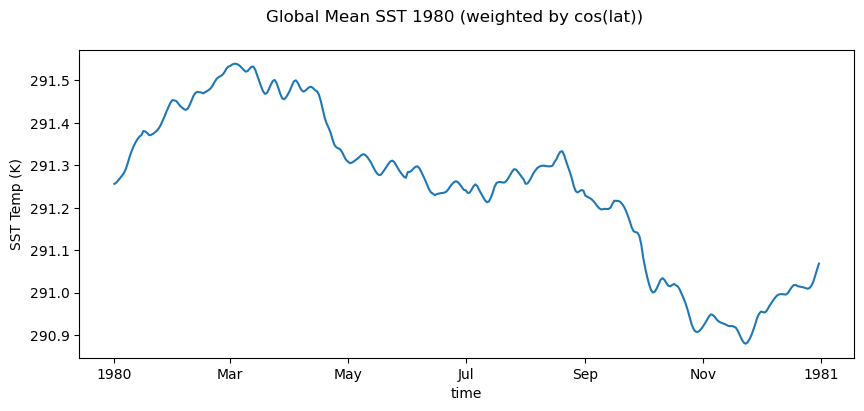

In [6]:
# plot the time series
fig,ax = plt.subplots(1,1, figsize=(10,4))
ds_sst_ts.sst.plot()
ax.set_ylabel("SST Temp (K)")
#ax.xaxis.set_tick_params(rotation=45)
plt.suptitle("Global Mean SST 1980 (weighted by cos(lat))")
plt.title("")

In [7]:
ds.chunks

Frozen({'time': (31, 29, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31), 'lat': (721,), 'lon': (1440,)})

### compute 75th percentile values for each grid cell

In [8]:
# load it into memory because I can't do quantile on on the dask dataset (also can't figure out how to do percentile)
ds.load()

<xarray.Dataset> Size: 2GB
Dimensions:      (time: 366, lat: 721, lon: 1440)
Coordinates:
  * time         (time) datetime64[ns] 3kB 1980-01-01 1980-01-02 ... 1980-12-31
    realization  int64 8B 0
  * lat          (lat) float64 6kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
  * lon          (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
Data variables:
    sst          (time, lat, lon) float32 2GB nan nan nan ... 271.5 271.5 271.5
Attributes:
    Conventions:  CF-1.7
    institution:  European Centre for Medium-Range Weather Forecasts
    history:      2024-08-29T01:46 GRIB to CDM+CF via cfgrib-0.9.9.1/ecCodes-...
    source:       ECMWF

In [10]:
%%time
#c_75 = ds.t2m.where(ds.t2m != 0).quantile(0.75, dim=('time'))
c_75 = ds.sst.quantile(0.75, dim=('time'), keep_attrs=True, skipna=True)
c_75

/Users/tedscott/anaconda3/envs/climate/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1634: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


CPU times: user 18 s, sys: 153 ms, total: 18.1 s
Wall time: 18.2 s


<xarray.DataArray 'sst' (lat: 721, lon: 1440)> Size: 4MB
array([[      nan,       nan,       nan, ...,       nan,       nan,
              nan],
       [      nan,       nan,       nan, ...,       nan,       nan,
              nan],
       [      nan,       nan,       nan, ...,       nan,       nan,
              nan],
       ...,
       [271.46042, 271.46042, 271.46042, ..., 271.46042, 271.46042,
        271.46042],
       [271.46042, 271.46042, 271.46042, ..., 271.46017, 271.46042,
        271.46042],
       [271.46042, 271.46042, 271.46042, ..., 271.46042, 271.46042,
        271.46042]], dtype=float32)
Coordinates:
  * lat       (lat) float64 6kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
  * lon       (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
    quantile  float64 8B 0.75
Attributes:
    long_name:      Sea surface temperature
    units:          K
    standard_name:  sea_surface_temperature
    comment:        Temperature of upper boundary of the liquid ocean, includ...
    type:           real

### plot one grid cell's time series and when it is above 75th percentile for the year, a.k.a. "summer"

Text(0, 0.5, 'Daily Temp (K)')

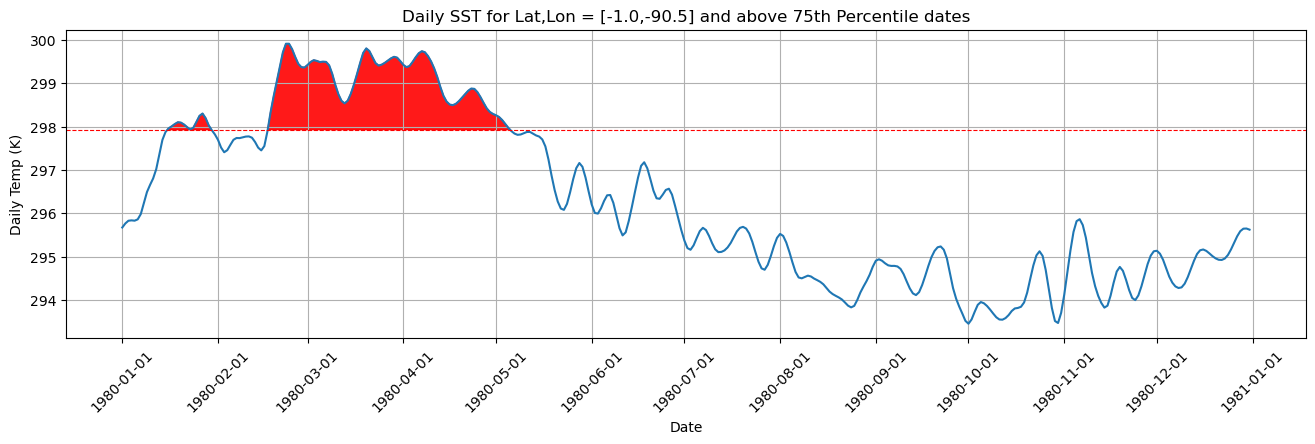

In [12]:
# plot for specific grid cell and the 75th percentile
plot_data = ds.sst.sel(lat=-1,lon=-90.5, method="nearest") # Galapagos Islands
plot_c_75 = c_75.sel(lat=-1,lon=-90.5, method="nearest")
plt.figure(figsize=(16,4))
plt.plot(plot_data.time, plot_data.data)
plt.fill_between(  # plot with color in between
    plot_data.time,  # x values
    # top boundary - y values above 0.5
    plot_data.data,
    plot_c_75,  # bottom boundary - 0.5
    where=(plot_data >= plot_c_75),
    color="red",  # color
    alpha=0.9,  # transparency value
    interpolate=True
)
plt.axhline(plot_c_75, color="red", linewidth=0.8, linestyle="dashed")
plt.tick_params(axis='x',rotation=45)
plt.xticks(["1980-01","1980-02","1980-03","1980-04","1980-05","1980-06",
           "1980-07","1980-08","1980-09","1980-10","1980-11","1980-12","1981-01"])
plt.grid()
#plt.ylim([280,315])
plt.title("Daily SST for Lat,Lon = [-1.0,-90.5] and above 75th Percentile dates")
plt.xlabel("Date")
plt.ylabel("Daily Temp (K)")


## Check polynomial fit

In [16]:
x1 = plot_data.time.dt.dayofyear.values
y1 = plot_data.values
#x1, y1
coefs = np.polyfit(x1, y1, 3)
poly = np.poly1d(coefs)

# other helpful guide at https://data36.com/polynomial-regression-python-scikit-learn/

Text(0, 0.5, 'Daily Temp (K)')

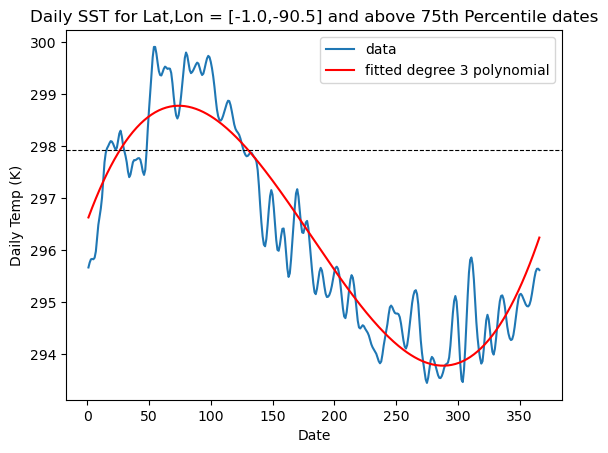

In [17]:
x_values = np.linspace(min(x1), max(x1), 366) # create some x values for plotting polynomial fit
plt.plot(x1,y1, label='data')
plt.plot(x_values, poly(x_values), label='fitted degree 3 polynomial', color='red')
plt.axhline(plot_c_75, color="black", linewidth=0.8, linestyle="dashed") 
plt.legend()
plt.title("Daily SST for Lat,Lon = [-1.0,-90.5] and above 75th Percentile dates")
plt.xlabel("Date")
plt.ylabel("Daily Temp (K)")


#### find summer length and also which days to add to figure


In [18]:
summer_length = np.count_nonzero(poly(x_values) >= plot_c_75.values)
summer_length

104

In [19]:
summer_days = np.where(poly(x_values) >= plot_c_75.values)[0]
summer_days

array([ 26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
       117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129])

In [20]:
first_day = x_values[min(summer_days)]
last_day = x_values[max(summer_days)]
first_day, last_day

(np.float64(27.0), np.float64(130.0))

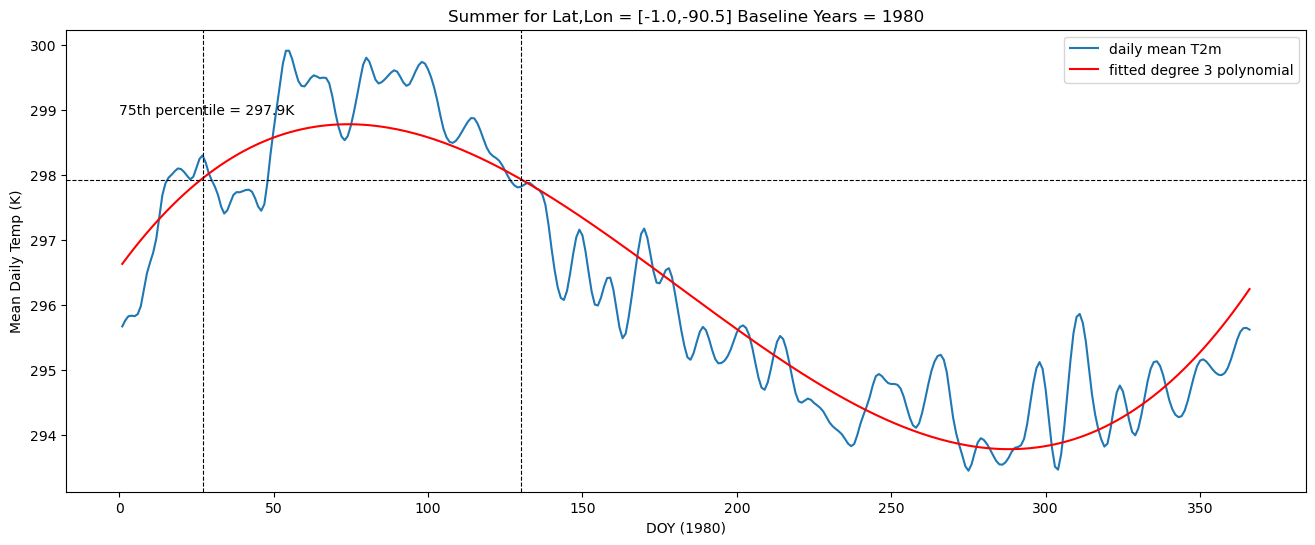

In [21]:
# make a new plot
x_values = np.linspace(min(x1), max(x1), 366) # create some x values for plotting polynomial fit
plt.figure(figsize=(16,6))
plt.plot(x1,y1, label='daily mean T2m')
plt.plot(x_values, poly(x_values), label='fitted degree 3 polynomial', color='red')
plt.axhline(plot_c_75.values, color="black", linewidth=0.8, linestyle="dashed") 
plt.axvline(first_day, color="black", linewidth=0.8, linestyle="dashed")
plt.axvline(last_day, color="black", linewidth=0.8, linestyle="dashed")
plt.annotate('summer = '+str(summer_length)+' days', xy=(first_day+5,280))
plt.annotate('75th percentile = '+str(np.round(plot_c_75.values,1))+'K', xy=(0,plot_c_75.values+1))
plt.xlabel('DOY (1980)')
plt.ylabel('Mean Daily Temp (K)')
plt.title("Summer for Lat,Lon = [-1.0,-90.5] Baseline Years = 1980")
plt.legend()


## Global map of 75th percentile SSTs

Text(0.5, 1.0, '75th Percentile SST from 1980')

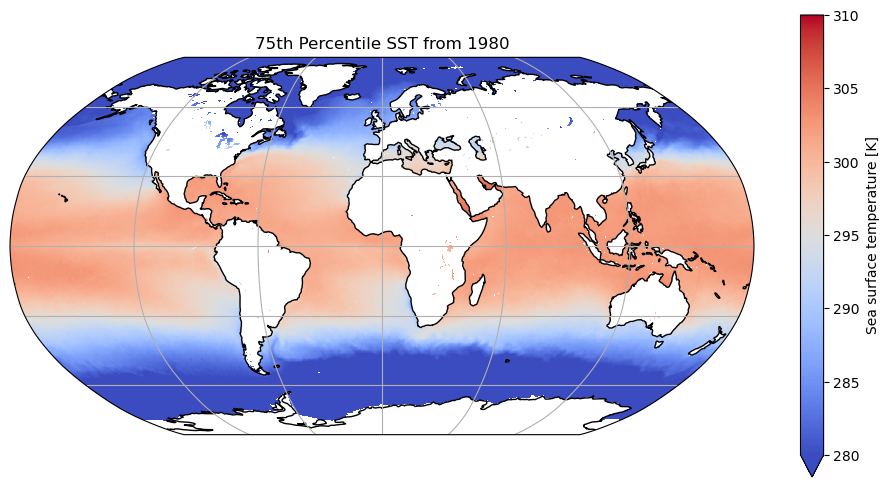

In [23]:
# plot first time entry
fig = plt.figure(figsize=(12,6))

# assign axis and def projection to use
ax = plt.axes(projection=ccrs.Robinson(central_longitude=0))

# add coastlines and grid
ax.coastlines()
ax.gridlines()

# plot first index of SSTs
c_75.plot(
    ax=ax,
    transform=ccrs.PlateCarree(), # assign map projection
    vmin=280,
    vmax=310, # define temp range for colorbar 230 to 310 K
    cmap="coolwarm"
)

plt.title("75th Percentile SST from 1980")